<a href="https://colab.research.google.com/github/Theanh130124/Medical_News/blob/master/vit_mae_xrays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision einops timm matplotlib wandb
!pip install kagglehub --upgrade
!pip install kaggle --upgrade
!pip install datasets --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.3/256.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 148.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 15.4 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 13.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Succ

#IMPORT THƯ VIỆN

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from einops import repeat, rearrange
from einops.layers.torch import Rearrange
from timm.models.vision_transformer import Block
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from timm.models.layers import trunc_normal_
from datasets import load_dataset
import wandb
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


#W&B Initialization

In [ ]:
wandb.init(project="mae-vit-chest-xray", entity=None)

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: theanhtran13012004 (theanhtran13012004-no) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


#CONFIGURATION

In [ ]:
config = wandb.config
config.learning_rate = 1e-4
config.batch_size = 32
config.epochs_mae = 70  # Pre-training epochs
config.epochs_classifier = 20  # Fine-tuning epochs
config.image_size = 224
config.patch_size = 16
config.emb_dim = 192 #emb vector ảnh
config.encoder_layer = 12
config.encoder_head = 6
config.decoder_layer = 4
config.decoder_head = 6
config.mask_ratio = 0.75 #Mask 75% ảnh
config.num_classes = 15 #Số classfications

# Load dataset

In [ ]:
from datasets import load_dataset, concatenate_datasets, DatasetDict

# Load dataset gốc
hf_ds = load_dataset("tta1301/nih-chest-xray-small")


full = concatenate_datasets([hf_ds["train"], hf_ds["validation"], hf_ds["test"]])

print("Tổng số mẫu sau khi gộp:", len(full))

# ------------------------------------------
# SPLIT 70/30
# ------------------------------------------
split_70_30 = full.train_test_split(test_size=0.30, seed=42)

# ------------------------------------------
# Tách 30% còn lại thành 15/15
# ------------------------------------------
val_test = split_70_30["test"].train_test_split(test_size=0.50, seed=42)

# Dataset mới theo tỷ lệ 70 / 15 / 15
new_ds = DatasetDict({
    "train": split_70_30["train"],
    "validation": val_test["train"],
    "test": val_test["test"]
})

print(new_ds)


README.md:   0%|          | 0.00/952 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/438M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/435M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/437M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/435M [00:00<?, ?B/s]

...

data/test-00001-of-00002.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4326 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1730 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1279 [00:00<?, ? examples/s]

Tổng số mẫu sau khi gộp: 7335
DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 5134
    })
    validation: Dataset({
        features: ['image', 'labels'],
        num_rows: 1100
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 1101
    })
})


#STRUCTURE DATASET

In [ ]:
## Kiểm tra cấu trúc dataset
print("Dataset structure:")
print(hf_ds)

print("\nFirst training sample:")
print(hf_ds["train"][0])

print("\nFeatures của dataset:")
print(hf_ds["train"].features)

print("\nKeys của một sample:")
print(hf_ds["train"][0].keys())

#NỮA NÊN ĐỂ CHUẨN (70/15/15 hoặc 80/10/10)

## Labels và mapping - FIXED
labels_list = hf_ds["train"].features["labels"].feature.names
print("Labels:", labels_list)
print("Number of classes:", len(labels_list))

label_to_idx = {label: idx for idx, label in enumerate(labels_list)}
print("Label to index mapping:", label_to_idx)

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 4326
    })
    validation: Dataset({
        features: ['image', 'labels'],
        num_rows: 1730
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 1279
    })
})

First training sample:
{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=1024x1024 at 0x7E7D343BFA70>, 'labels': [0]}

Features của dataset:
{'image': Image(mode=None, decode=True), 'labels': List(ClassLabel(names=['No Finding', 'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']))}

Keys của một sample:
dict_keys(['image', 'labels'])
Labels: ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'H

#MyDataset

In [ ]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset[idx]
        # Xử lý ảnh - chuyển từ grayscale (mode L) sang RGB
        img = row["image"].convert("RGB")
        if self.transform:
            img = self.transform(img)
        # Xử lý nhãn - tạo multi-hot vector
        encoded_label = torch.zeros(len(labels_list), dtype=torch.float32)
        # row["labels"] là list các class index (ví dụ: [0] hoặc [1, 3, 5])
        for label_idx in row["labels"]:
            encoded_label[label_idx] = 1.0

        return img, encoded_label

#--- Transform ---


In [ ]:
#ảnh về tensor

img_size = config.image_size
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

#--- DataLoader ---

In [ ]:
train_dataset = MyDataset(hf_ds["train"], train_transform)
val_dataset   = MyDataset(hf_ds["validation"], val_transform)
test_dataset  = MyDataset(hf_ds["test"], val_transform)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=4)

In [ ]:
# Kiểm tra dữ liệu
print(f"\nDataset sizes:")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Kiểm tra một batch
for images, labels in train_loader:
    print(f"\nBatch images shape: {images.shape}")  # [32, 3, 224, 224]
    print(f"Batch labels shape: {labels.shape}")    # [32, 15] - 15 classes
    print(f"Label range: {labels.min()} - {labels.max()}")  # 0.0 - 1.0
    print(f"Sample label: {labels[0]}")  # Multi-hot vector
    break


Dataset sizes:
Train samples: 4326
Val samples: 1730
Test samples: 1279

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32, 15])
Label range: 0.0 - 1.0
Sample label: tensor([0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


# --- Các hàm utility ---

In [ ]:
#để nữa random patches ảnh và khôi phục lại .

def random_indexes(size: int):
    forward_indexes = np.arange(size)
    np.random.shuffle(forward_indexes)
    backward_indexes = np.argsort(forward_indexes)
    return forward_indexes, backward_indexes

def take_indexes(sequences, indexes):
    return torch.gather(sequences, 0, repeat(indexes, 't b -> t b c', c=sequences.shape[-1]))

#Các lớp MAE

In [ ]:
# --- Block Transformer ---
class Block(nn.Module):
    def __init__(self, emb_dim, num_head):
        super().__init__()
        self.ln_1 = nn.LayerNorm(emb_dim)
        self.attention = nn.MultiheadAttention(emb_dim, num_head, batch_first=True) #MultiheadAttention
        self.ln_2 = nn.LayerNorm(emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4),
            nn.GELU(), #Phi tuyến để học sâu -> tránh quá tuyến tính
            nn.Linear(emb_dim * 4, emb_dim)
        )

    def forward(self, x):
        attn_out, _ = self.attention(self.ln_1(x), self.ln_1(x), self.ln_1(x))  # Self-attetion -> Các patches xung quanh
        x = x + attn_out
        x = x + self.mlp(self.ln_2(x)) #Học sâu của từng patches đó
        return x

# --- Patch Shuffle ---
class PatchShuffle(nn.Module):
    def __init__(self, ratio) -> None:
        super().__init__()
        self.ratio = ratio #Mask 75%
    def forward(self, patches: torch.Tensor):
        T, B, C = patches.shape #Số patches , batchsize, chiều
        remain_T = int(T * (1 - self.ratio))# remain (sổ ảnh giữ lại là 25%)

        #random mask ghi lại index để có thể backward lại
        indexes = [random_indexes(T) for _ in range(B)]
        forward_indexes = torch.as_tensor(np.stack([i[0] for i in indexes], axis=-1), dtype=torch.long).to(patches.device)
        backward_indexes = torch.as_tensor(np.stack([i[1] for i in indexes], axis=-1), dtype=torch.long).to(patches.device)

        patches = take_indexes(patches, forward_indexes)
        patches = patches[:remain_T]

        return patches, forward_indexes, backward_indexes
# --- MAE Encoder ----

class MAE_Encoder(nn.Module):
    def __init__(self, image_size=224, patch_size=16, emb_dim=192, num_layer=12, num_head=3, mask_ratio=0.75) -> None:
        super().__init__()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        num_patches = (image_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.zeros(num_patches, 1, emb_dim))
        self.shuffle = PatchShuffle(mask_ratio)
        self.patchify = nn.Conv2d(3, emb_dim, patch_size, patch_size) #1.Cắt ảnh 196 patches
        self.transformer = nn.Sequential(*[Block(emb_dim, num_head) for _ in range(num_layer)])
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.init_weight()

    def init_weight(self):
        trunc_normal_(self.cls_token, std=.02)
        trunc_normal_(self.pos_embedding, std=.02)

    def forward(self, img):
        patches = self.patchify(img)
        patches = rearrange(patches, 'b c h w -> (h w) b c')

        assert patches.shape[0] == self.pos_embedding.shape[0], (
            f"Mismatch: patches {patches.shape[0]} vs pos_embedding {self.pos_embedding.shape[0]}"
        )

        patches = patches + self.pos_embedding #2.gán vị trí từng patches
        patches, forward_indexes, backward_indexes = self.shuffle(patches) #3.mask 75%
        patches = torch.cat([self.cls_token.expand(-1, patches.shape[1], -1), patches], dim=0) #4.CLS Token -> ghi các thông tin của toàn bộ patches trong quá trình self attetion
        patches = rearrange(patches, 't b c -> b t c') # (batch, time, channel)
        features = self.layer_norm(self.transformer(patches))
        features = rearrange(features, 'b t c -> t b c')
        return features, backward_indexes
# --- MAE Decoder  ---
class MAE_Decoder(nn.Module):
    def __init__(self, image_size=224, patch_size=16, emb_dim=192, num_layer=4, num_head=3) -> None:
        super().__init__()
        self.mask_token = nn.Parameter(torch.zeros(1, 1, emb_dim)) #1.thêm vùng trắng cho mask bị che
        num_patches = (image_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.zeros(num_patches + 1, 1, emb_dim))
        self.transformer = nn.Sequential(*[Block(emb_dim, num_head) for _ in range(num_layer)])
        self.head = nn.Linear(emb_dim, 3 * patch_size ** 2) #3. vẽ lại các patches bị giấu - dùng tranformer + head
        self.patch2img = Rearrange('(h w) b (c p1 p2) -> b c (h p1) (w p2)',
                                   p1=patch_size, p2=patch_size, h=image_size // patch_size)
        self.init_weight()

    def init_weight(self):
        trunc_normal_(self.mask_token, std=.02)
        trunc_normal_(self.pos_embedding, std=.02)

    def forward(self, features, backward_indexes):
        T = features.shape[0] # # 50 (49 patches + 1 CLS từ encoder)
        backward_indexes = torch.cat([torch.zeros(1, backward_indexes.shape[1]).to(backward_indexes), backward_indexes + 1], dim=0)
        features = torch.cat([features, self.mask_token.expand(backward_indexes.shape[0] - features.shape[0], features.shape[1], -1)], dim=0)
        features = take_indexes(features, backward_indexes) #2. sắp lại đúng ví trí -> Do Encoder đã xáo trộn thứ tự patches .
        features = features + self.pos_embedding
        features = rearrange(features, 't b c -> b t c') #format  Cho transformer
        features = self.transformer(features) # "Suy nghĩ" để vẽ
        features = rearrange(features, 'b t c -> t b c')
        features = features[1:]  # Remove CLS token
        patches = self.head(features) # BỎ CLS TOKEN - chỉ cần 196 patches
        img = self.patch2img(patches) #4. Ghép các patches thành ảnh toàn vẹn
        return img

#ViT -> (Gán endcoder và decoder lại)

In [ ]:
# --- MAE ViT cho Pre-training ---
class MAE_ViT(nn.Module):
    def __init__(self, image_size=224, patch_size=16, emb_dim=192, encoder_layer=12, encoder_head=6, decoder_layer=4, decoder_head=6, mask_ratio=0.75) -> None:
        super().__init__()
        self.encoder = MAE_Encoder(image_size, patch_size, emb_dim, encoder_layer, encoder_head, mask_ratio)
        self.decoder = MAE_Decoder(image_size, patch_size, emb_dim, decoder_layer, decoder_head)

    def forward(self, img):
        features, backward_indexes = self.encoder(img)
        predicted_img = self.decoder(features, backward_indexes)
        return predicted_img

# --- Classification Head cho Kết quả từ encoder---
#Encoder trả ra 192 features → 15 bệnh
class ClassificationHead(nn.Module):
    def __init__(self, emb_dim, num_classes):
        super().__init__()
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # x: CLS token từ encoder [batch_size, emb_dim]
        x = self.norm(x)
        return self.head(x)

# --- ViT cho Classification  ---
class ViT_Classifier(nn.Module):
    def __init__(self, image_size=224, patch_size=16, emb_dim=192, num_layer=12, num_head=3, num_classes=15):
        super().__init__()
        self.patchify = nn.Conv2d(3, emb_dim, patch_size, patch_size)
        num_patches = (image_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, emb_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.transformer = nn.Sequential(*[Block(emb_dim, num_head) for _ in range(num_layer)])
        self.classifier = ClassificationHead(emb_dim, num_classes)
        self.init_weight()

    def init_weight(self):
        trunc_normal_(self.cls_token, std=.02)
        trunc_normal_(self.pos_embedding, std=.02)

    def forward(self, img):
        patches = self.patchify(img)
        patches = rearrange(patches, 'b c h w -> b (h w) c')

        cls_tokens = self.cls_token.expand(img.shape[0], -1, -1)
        patches = torch.cat([cls_tokens, patches], dim=1)
        patches = patches + self.pos_embedding

        features = self.transformer(patches)
        cls_features = features[:, 0]  # Lấy CLS token
        logits = self.classifier(cls_features)
        return logits


In [ ]:
# Giải thích
# F1-micro: tính tổng TP, FP, FN trên tất cả class trước khi tính F1.
# Ưu tiên các class phổ biến → nhạy với class imbalance.
# F1-macro: tính F1 riêng cho từng class, sau đó lấy trung bình → cân nhắc đều tất cả class, bất kể class phổ biến hay hiếm.
# Ví dụ tính tay đơn giản
# Class A
# TP = 2 (sample 1 và 3 đúng), FP = 0, FN = 0 → F1 = 1.0
# Class B
# TP = 1 (sample 2), FP = 0, FN = 1 (sample 3 missed B) → F1 = 0.6667
# Class C
# TP = 1 (sample 4), FP = 1 (sample 2 đoán C sai), FN = 1 (sample 1 missed C) → F1 = 0.5
# F1-macro = (1.0 + 0.6667 + 0.5)/3 ≈ 0.722
# F1-micro = tổng TP = 4, tổng FP = 1, tổng FN = 2
# Precision = 4 / (4+1) = 0.8
# Recall = 4 / (4+2) ≈ 0.6667
# F1-micro = 2 * 0.8 * 0.6667 / (0.8 + 0.6667) ≈ 0.727

#MAE

In [ ]:

# --- Evaluation -> Loss + Accuracy function cho Classification ---
def evaluate_classifier(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for img, labels in data_loader:
            img, labels = img.to(device), labels.to(device)
            logits = model(img)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            # FIX: Tính accuracy ĐÚNG cho multi-label
            preds = torch.sigmoid(logits) > 0.5
            correct_per_sample = (preds == labels).sum(dim=1).float()
            total_possible = labels.size(1)
            sample_accuracy = correct_per_sample / total_possible

            correct += sample_accuracy.sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total if total > 0 else 0
    return avg_loss, accuracy


#Xem ảnh MAE tạo
def visualize_mae_reconstruction(model, dataloader, device, epoch, num_images=3):
    """
    Visualize MAE reconstructions without blocking training
    """
    model.eval()
    with torch.no_grad():
        # Get a batch of data without using the dataloader iterator
        data_iter = iter(dataloader)
        images, _ = next(data_iter)
        images = images.to(device)

        # Get MAE reconstruction
        reconstructed = model(images)

        # Convert to numpy
        images_np = images.cpu().numpy()
        reconstructed_np = reconstructed.cpu().numpy()

        # Plot
        fig, axes = plt.subplots(2, num_images, figsize=(12, 6))

        for i in range(num_images):
            # Original
            orig_img = np.transpose(images_np[i], (1, 2, 0))
            orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
            axes[0, i].imshow(orig_img)
            axes[0, i].set_title(f'Original {i+1}')
            axes[0, i].axis('off')

            # Reconstructed
            recon_img = np.transpose(reconstructed_np[i], (1, 2, 0))
            recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min())
            axes[1, i].imshow(recon_img)
            axes[1, i].set_title(f'Reconstructed {i+1}')
            axes[1, i].axis('off')

        plt.suptitle(f'MAE - Epoch {epoch+1}')
        plt.tight_layout()

        # Save and show without blocking
        plt.savefig(f'mae_epoch_{epoch+1}.png', dpi=150, bbox_inches='tight')
        plt.show(block=False)  # Non-blocking show
        plt.pause(2)  # Hiển thị trong 2 giây
        plt.close()

        print(f"Đã hiển thị MAE reconstruction epoch {epoch+1}")


# --- Training function cho MAE Pre-training ---
def train_mae_one_epoch(model, optimizer, criterion, data_loader, device, epoch, visualize_epochs=None):
    model.train()
    total_loss = 0
    data_loader = tqdm(data_loader, desc=f"[MAE Pre-train Epoch {epoch}]")

    for step, (img, _) in enumerate(data_loader):
        img = img.to(device)
        optimizer.zero_grad()

        predicted_img = model(img)
        loss = criterion(predicted_img, img)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        data_loader.set_postfix({"loss": total_loss / (step + 1)})

    avg_loss = total_loss / len(data_loader)
    print(f"[MAE Pre-train Epoch {epoch}] Average Loss: {avg_loss:.4f}")

    # Visualization tại các epoch chỉ định
    if visualize_epochs is not None and (epoch + 1) in visualize_epochs:
        print(f" Visualizing MAE tại epoch {epoch + 1}...")
        visualize_mae_reconstruction(model, data_loader, device, epoch)  # Dùng hàm mới

    # Log to W&B
    wandb.log({
        "mae_pretrain_loss": avg_loss,
        "mae_epoch": epoch
    })

    return avg_loss


#Classification với ViT + Encoder MAE

In [ ]:
# --- Training function cho Classification Fine-tuning ---
def train_classifier_one_epoch(model, optimizer, criterion, data_loader, device, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    data_loader = tqdm(data_loader, desc=f"[Classification Epoch {epoch}]")

    for step, (img, labels) in enumerate(data_loader):
        img, labels = img.to(device), labels.to(device)
        optimizer.zero_grad()

        logits = model(img)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # FIX: Tính accuracy ĐÚNG cho multi-label
        preds = torch.sigmoid(logits) > 0.5
        # Tính số labels đúng cho mỗi sample, rồi lấy trung bình
        correct_per_sample = (preds == labels).sum(dim=1).float()
        total_possible = labels.size(1)  # = 15 classes
        sample_accuracy = correct_per_sample / total_possible

        correct += sample_accuracy.sum().item()
        total += labels.size(0)

        data_loader.set_postfix({
            "loss": total_loss / (step + 1),
            "acc": correct / total if total > 0 else 0
        })

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total if total > 0 else 0
    print(f"[Classification Epoch {epoch}] Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

    return avg_loss, accuracy


#Train trên dataset

Bắt đầu training toàn bộ pipeline...
Using device: cuda
=== Phase 1: MAE Pre-training ===


[MAE Pre-train Epoch 0]: 100%|██████████| 136/136 [01:28<00:00,  1.54it/s, loss=0.771]

[MAE Pre-train Epoch 0] Average Loss: 0.7709
 Visualizing MAE tại epoch 1...


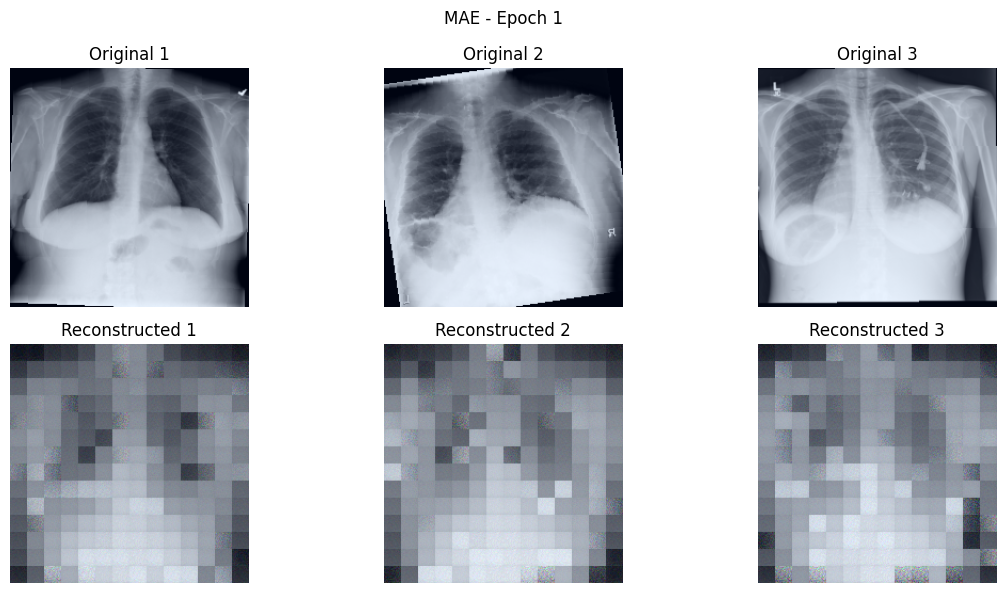

Đã hiển thị MAE reconstruction epoch 1


[MAE Pre-train Epoch 1]: 100%|██████████| 136/136 [01:27<00:00,  1.56it/s, loss=0.489]


[MAE Pre-train Epoch 1] Average Loss: 0.4895


[MAE Pre-train Epoch 2]: 100%|██████████| 136/136 [01:25<00:00,  1.59it/s, loss=0.449]


[MAE Pre-train Epoch 2] Average Loss: 0.4488


...

[MAE Pre-train Epoch 6] Average Loss: 0.3778


[MAE Pre-train Epoch 7]: 100%|██████████| 136/136 [01:26<00:00,  1.58it/s, loss=0.366]


[MAE Pre-train Epoch 7] Average Loss: 0.3658


[MAE Pre-train Epoch 8]: 100%|██████████| 136/136 [01:26<00:00,  1.57it/s, loss=0.353]

[MAE Pre-train Epoch 8] Average Loss: 0.3526
 Visualizing MAE tại epoch 9...


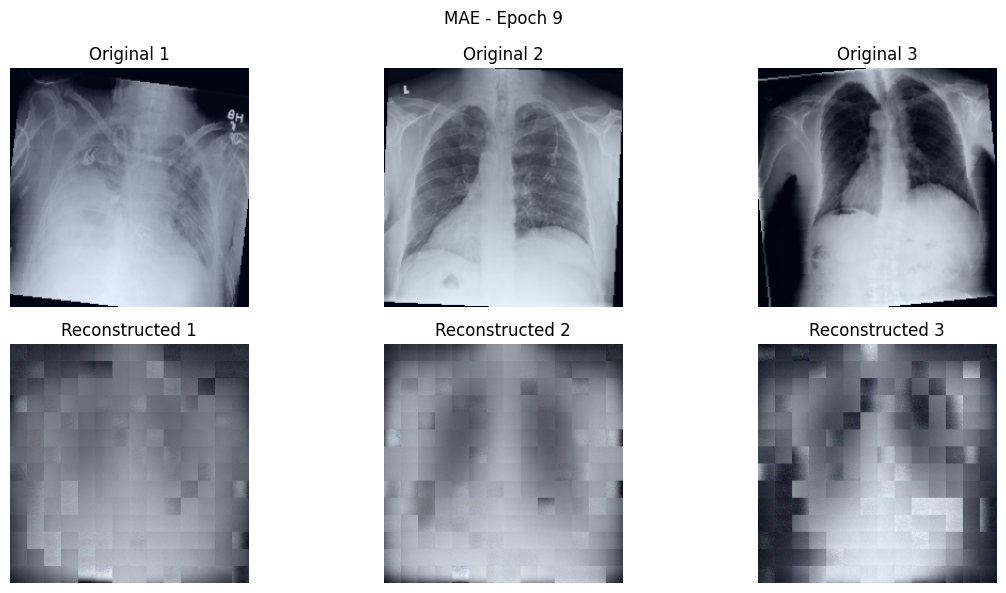

Đã hiển thị MAE reconstruction epoch 9


[MAE Pre-train Epoch 9]: 100%|██████████| 136/136 [01:27<00:00,  1.55it/s, loss=0.331]


[MAE Pre-train Epoch 9] Average Loss: 0.3314


[MAE Pre-train Epoch 10]: 100%|██████████| 136/136 [01:27<00:00,  1.55it/s, loss=0.315]


[MAE Pre-train Epoch 10] Average Loss: 0.3155


...

[MAE Pre-train Epoch 16] Average Loss: 0.2591


[MAE Pre-train Epoch 17]: 100%|██████████| 136/136 [01:27<00:00,  1.56it/s, loss=0.25]


[MAE Pre-train Epoch 17] Average Loss: 0.2505


[MAE Pre-train Epoch 18]: 100%|██████████| 136/136 [01:27<00:00,  1.56it/s, loss=0.243]

[MAE Pre-train Epoch 18] Average Loss: 0.2431
 Visualizing MAE tại epoch 19...


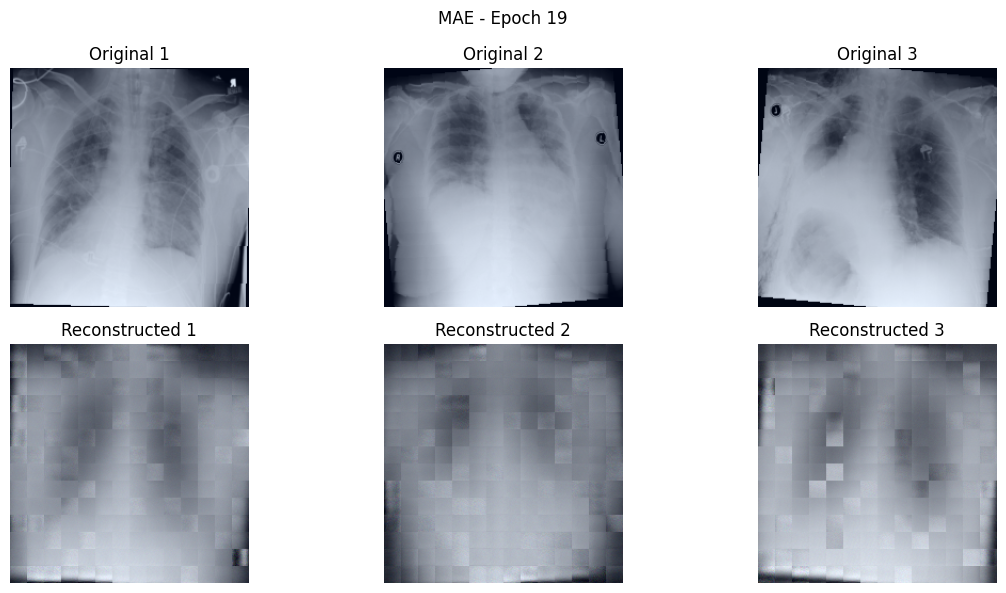

Đã hiển thị MAE reconstruction epoch 19


[MAE Pre-train Epoch 19]: 100%|██████████| 136/136 [01:30<00:00,  1.50it/s, loss=0.24]


[MAE Pre-train Epoch 19] Average Loss: 0.2401


[MAE Pre-train Epoch 20]: 100%|██████████| 136/136 [01:28<00:00,  1.54it/s, loss=0.235]


[MAE Pre-train Epoch 20] Average Loss: 0.2353


...

[MAE Pre-train Epoch 26] Average Loss: 0.2081


[MAE Pre-train Epoch 27]: 100%|██████████| 136/136 [01:29<00:00,  1.52it/s, loss=0.203]


[MAE Pre-train Epoch 27] Average Loss: 0.2035


[MAE Pre-train Epoch 28]: 100%|██████████| 136/136 [01:28<00:00,  1.54it/s, loss=0.201]

[MAE Pre-train Epoch 28] Average Loss: 0.2015
 Visualizing MAE tại epoch 29...


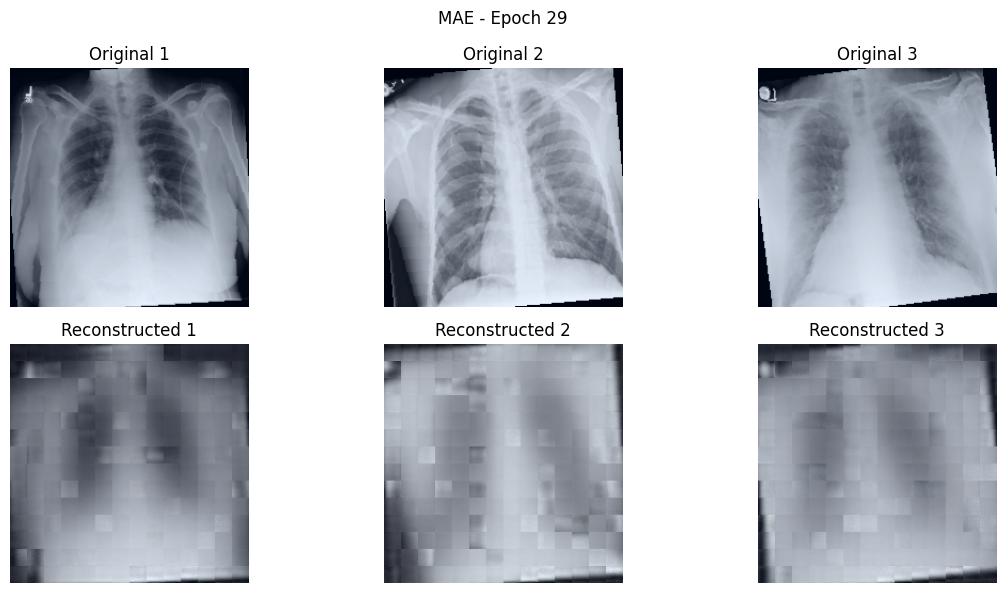

Đã hiển thị MAE reconstruction epoch 29


[MAE Pre-train Epoch 29]: 100%|██████████| 136/136 [01:29<00:00,  1.51it/s, loss=0.196]


[MAE Pre-train Epoch 29] Average Loss: 0.1964


[MAE Pre-train Epoch 30]: 100%|██████████| 136/136 [01:29<00:00,  1.51it/s, loss=0.193]


[MAE Pre-train Epoch 30] Average Loss: 0.1934


...

[MAE Pre-train Epoch 36] Average Loss: 0.1770


[MAE Pre-train Epoch 37]: 100%|██████████| 136/136 [01:29<00:00,  1.52it/s, loss=0.175]


[MAE Pre-train Epoch 37] Average Loss: 0.1750


[MAE Pre-train Epoch 38]: 100%|██████████| 136/136 [01:31<00:00,  1.49it/s, loss=0.169]

[MAE Pre-train Epoch 38] Average Loss: 0.1691
 Visualizing MAE tại epoch 39...


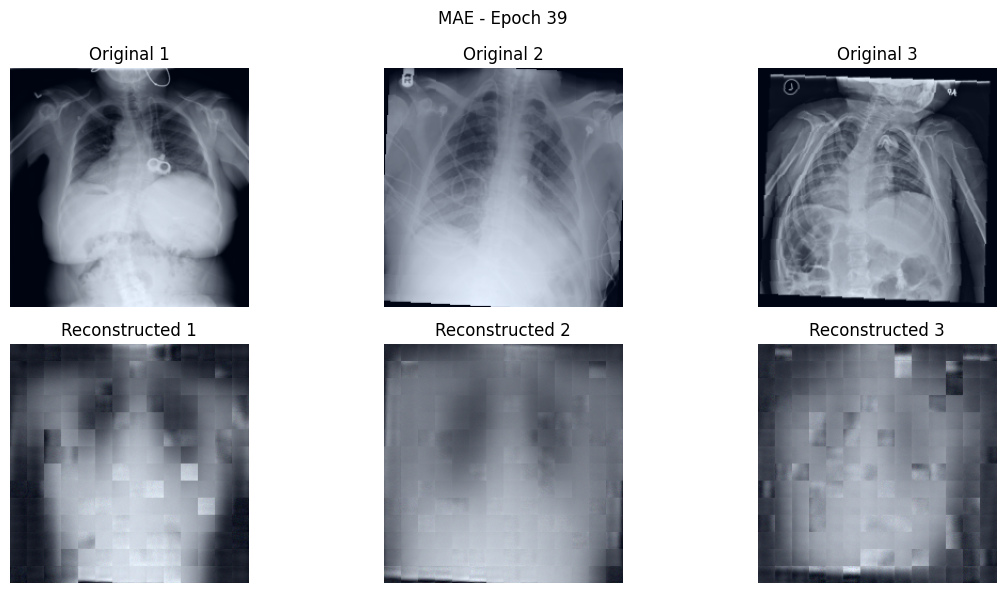

Đã hiển thị MAE reconstruction epoch 39


[MAE Pre-train Epoch 39]: 100%|██████████| 136/136 [01:32<00:00,  1.48it/s, loss=0.169]


[MAE Pre-train Epoch 39] Average Loss: 0.1691


[MAE Pre-train Epoch 40]: 100%|██████████| 136/136 [01:30<00:00,  1.49it/s, loss=0.164]


[MAE Pre-train Epoch 40] Average Loss: 0.1640


...

[MAE Pre-train Epoch 46] Average Loss: 0.1510


[MAE Pre-train Epoch 47]: 100%|██████████| 136/136 [01:32<00:00,  1.47it/s, loss=0.149]


[MAE Pre-train Epoch 47] Average Loss: 0.1495


[MAE Pre-train Epoch 48]: 100%|██████████| 136/136 [01:30<00:00,  1.50it/s, loss=0.147]

[MAE Pre-train Epoch 48] Average Loss: 0.1471
 Visualizing MAE tại epoch 49...


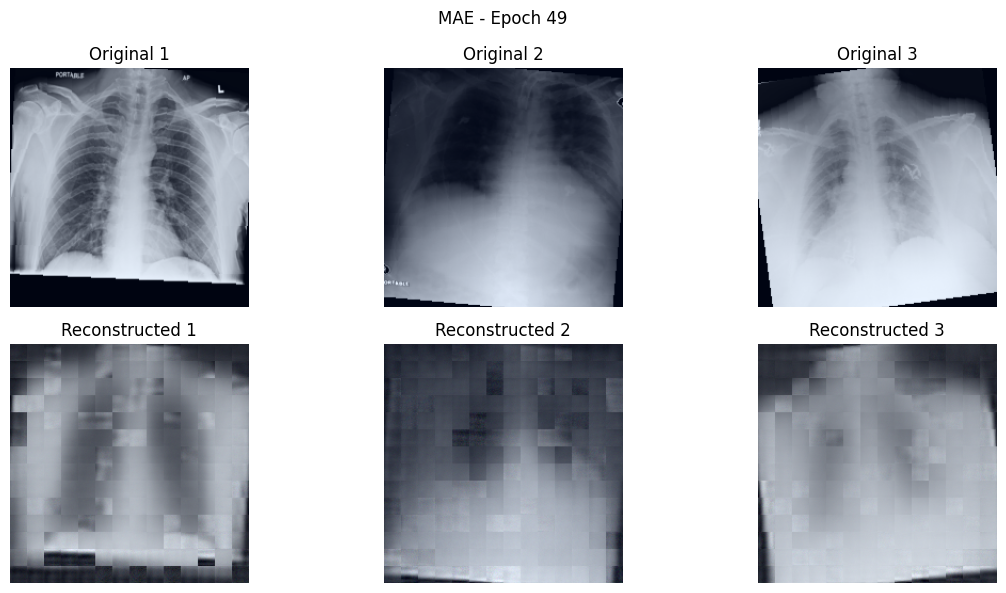

Đã hiển thị MAE reconstruction epoch 49


[MAE Pre-train Epoch 49]: 100%|██████████| 136/136 [01:32<00:00,  1.46it/s, loss=0.146]


[MAE Pre-train Epoch 49] Average Loss: 0.1461


[MAE Pre-train Epoch 50]: 100%|██████████| 136/136 [01:33<00:00,  1.46it/s, loss=0.143]


[MAE Pre-train Epoch 50] Average Loss: 0.1430


...

[Validation Epoch 18] Loss: 0.2063, Accuracy: 0.9299


[Classification Epoch 19]: 100%|██████████| 136/136 [01:31<00:00,  1.49it/s, loss=0.204, acc=0.931]

[Classification Epoch 19] Loss: 0.2041, Accuracy: 0.9306


[Validation Epoch 19] Loss: 0.2050, Accuracy: 0.9307
New best model saved with validation accuracy: 0.9307

=== Final Test ===
Test Results - Loss: 0.2658, Accuracy: 0.9025


classification_epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
classification_train_acc,▁███████████████████
classification_train_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
classification_val_acc,▁▆▆▇▆▆▅▆▇▅▆▆▅▅▇▇▅▇▄█
classification_val_loss,█▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
mae_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█
mae_pretrain_loss,█▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_accuracy,▁
test_loss,▁
classification_epoch,19
classification_train_acc,0.93064


In [ ]:

# --- Main Training Loop ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Định nghĩa các epoch muốn visualize
    visualize_epochs = [1, 9, 19, 29, 39, 49]

    # Phase 1: MAE Học ảnh
    print("=== Phase 1: MAE Pre-training ===")
    mae_model = MAE_ViT(
        image_size=config.image_size,
        patch_size=config.patch_size,
        emb_dim=config.emb_dim,
        encoder_layer=config.encoder_layer,
        encoder_head=config.encoder_head,
        decoder_layer=config.decoder_layer,
        decoder_head=config.decoder_head,
        mask_ratio=config.mask_ratio
    ).to(device)

    mae_optimizer = torch.optim.AdamW(mae_model.parameters(), lr=config.learning_rate, weight_decay=0.05) #Các siêu tham số..
    mae_criterion = nn.MSELoss() #So sánh pixel-to-pixel -> tính loss

    # Train MAE -> Không có nhãn nên k có accuracy
    for epoch in range(config.epochs_mae):
        mae_loss = train_mae_one_epoch(mae_model, mae_optimizer, mae_criterion, train_loader, device, epoch,visualize_epochs)

        # Save MAE model checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': mae_model.state_dict(),
                'optimizer_state_dict': mae_optimizer.state_dict(),
                'loss': mae_loss, #ảnh gốc so vs ảnh tạo -> so sánh dựa vào pixcels Mean Squared Error (MSE)
            }, f'mae_checkpoint_epoch_{epoch+1}.pth')



    # Phase 2: Classification Fine-tuning
    print("\n=== Phase 2: Classification Fine-tuning ===")

    # Initialize classifier with pre-trained encoder weights
    classifier_model = ViT_Classifier(  #Encoder MAE cho phần này
        image_size=config.image_size,
        patch_size=config.patch_size,
        emb_dim=config.emb_dim,
        num_layer=config.encoder_layer,
        num_head=config.encoder_head,
        num_classes=config.num_classes
    ).to(device)

    # Transfer encoder weights from MAE to classifier
    classifier_model.patchify.load_state_dict(mae_model.encoder.patchify.state_dict())
    classifier_model.transformer.load_state_dict(mae_model.encoder.transformer.state_dict()) #Copy weights từ MAE encoder sang classifier encoder

    classifier_optimizer = torch.optim.AdamW(classifier_model.parameters(), lr=config.learning_rate/40, weight_decay=0.05)
    classifier_criterion = nn.BCEWithLogitsLoss()

    best_val_acc = 0

    for epoch in range(config.epochs_classifier):
        # Training ViT
        train_loss, train_acc = train_classifier_one_epoch(
            classifier_model, classifier_optimizer, classifier_criterion, train_loader, device, epoch
        )

        # Validation
        val_loss, val_acc = evaluate_classifier(classifier_model, val_loader, device)
        print(f"[Validation Epoch {epoch}] Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

        # Log to W&B
        wandb.log({
            "classification_train_loss": train_loss,
            "classification_train_acc": train_acc,
            "classification_val_loss": val_loss,
            "classification_val_acc": val_acc,
            "classification_epoch": epoch
        })

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': classifier_model.state_dict(),
                'optimizer_state_dict': classifier_optimizer.state_dict(),
                'val_acc': val_acc,
            }, 'best_classifier_model.pth')
            print(f"New best model saved with validation accuracy: {val_acc:.4f}")

    # Final Test
    print("\n=== Final Test ===")
    classifier_model.load_state_dict(torch.load('best_classifier_model.pth')['model_state_dict'])
    test_loss, test_acc = evaluate_classifier(classifier_model, test_loader, device)
    print(f"Test Results - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

    # Log test results
    wandb.log({
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })

    wandb.finish()
if __name__ == "__main__":
    print("Bắt đầu training toàn bộ pipeline...")
    main()

In [ ]:
from huggingface_hub import Repository, login
import torch
import os
import shutil
import subprocess

# --- Login Hugging Face ---
login()

# --- Thông tin repo ---
repo_name = "xray-vit-classifier"
repo_local_dir = "./hf_repo"
your_username = "tta1301"

# --- Xóa thư mục cũ nếu có ---
if os.path.exists(repo_local_dir):
    shutil.rmtree(repo_local_dir)

# --- Clone repo trực tiếp từ Hugging Face ---
repo = Repository(
    local_dir=repo_local_dir,
    clone_from=f"{your_username}/{repo_name}",
    use_auth_token=True
)

# --- CẤU HÌNH GIT (QUAN TRỌNG) ---
# Cấu hình user name và email cho git
subprocess.run(["git", "config", "user.email", "theanhtran13012004@gmail.com"], cwd=repo_local_dir, check=True)
subprocess.run(["git", "config", "user.name", "tta1301"], cwd=repo_local_dir, check=True)

# --- Lưu model và config ---
torch.save(torch.load("best_classifier_model.pth")['model_state_dict'], f"{repo_local_dir}/pytorch_model.bin")
torch.save({
    'image_size': config.image_size,
    'patch_size': config.patch_size,
    'emb_dim': config.emb_dim,
    'num_layer': config.encoder_layer,
    'num_head': config.encoder_head,
    'num_classes': config.num_classes
}, f"{repo_local_dir}/config.pth")

# --- Thêm README ---
with open(f"{repo_local_dir}/README.md", "w") as f:
    f.write("# ViT Classifier for X-ray\n\nPretrained MAE + Fine-tuned classifier for image classification.")

# --- Push lên Hugging Face Hub ---
repo.push_to_hub(commit_message="Upload ViT classifier model")



Cloning https://huggingface.co/tta1301/xray-vit-classifier into local empty directory.


Download file pytorch_model.bin:   0%|          | 16.0k/21.1M [00:00<?, ?B/s]

Download file config.pth: 100%|##########| 1.29k/1.29k [00:00<?, ?B/s]

Clean file config.pth:  78%|#######7  | 1.00k/1.29k [00:00<?, ?B/s]

Clean file pytorch_model.bin:   0%|          | 1.00k/21.1M [00:00<?, ?B/s]

Upload file pytorch_model.bin:   0%|          | 1.00/21.1M [00:00<?, ?B/s]

To https://huggingface.co/tta1301/xray-vit-classifier
   fff8f6e..051178e  main -> main

   fff8f6e..051178e  main -> main



✅ Model đã được push lên Hugging Face Hub!
